In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy
import matplotlib.pylab as pylab
import matplotlib.axes as axes
from scipy.optimize import curve_fit
import ROOT as root
from ROOT import TH2F
from ROOT import TCanvas
import json

params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'xtick.direction':'in',
         'ytick.direction':'in',
         'xtick.bottom':'True',
         'xtick.top':'True',
         'ytick.right':'True',
         'xtick.major.width':1.5,
         'ytick.major.width':1.5,
         'xtick.major.size':6,
         'ytick.major.size':6}
pylab.rcParams.update(params)

Linestyle = 'solid'
Linestyle2 = 'dashed'
Linestyle3 = 'dotted'
Linestyle4 = (0,(5,10))
Linestyle5 = "None"

Welcome to JupyROOT 6.30/04


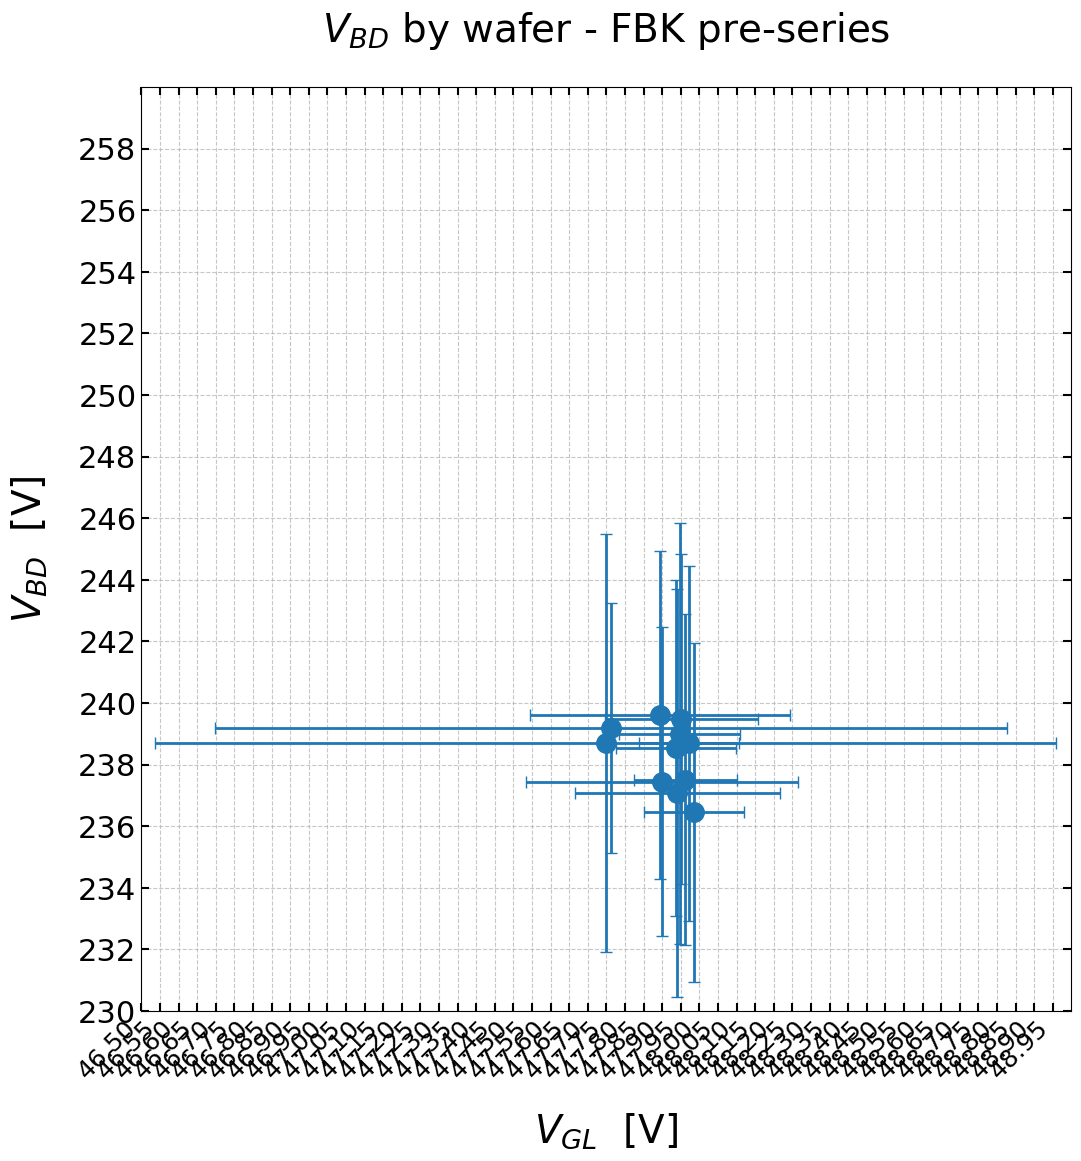

In [2]:
save_path = '/Users/icosivi/Desktop/PRE-SERIE/FBK/'
mean_vbd = []
sigma_vbd = []
mean_vgl = []
sigma_vgl = []

with open(save_path+"mean_VBD.json", "r", encoding="utf-8") as f:
            mean_vbd =  json.load(f)
            
with open(save_path+"sigma_VBD.json", "r", encoding="utf-8") as f:
            sigma_vbd =  json.load(f)
            
with open(save_path+"mean_VGL.json", "r", encoding="utf-8") as f:
            mean_vgl =  json.load(f)
            
with open(save_path+"sigma_VGL.json", "r", encoding="utf-8") as f:
            sigma_vgl =  json.load(f)

plt.figure(figsize=(12, 12))
plt.errorbar(mean_vgl,mean_vbd,xerr=sigma_vgl,yerr=sigma_vbd,linewidth=0,elinewidth=2,capsize=4,fmt='o-',markersize=14)
plt.xlabel('$V_{GL}$  [V]',fontsize=28,labelpad=20)
plt.ylabel("$V_{BD}$  [V]",fontsize=28,labelpad=20)
plt.ylim(230,260)
plt.xlim(46.5,49)
plt.title('$V_{BD}$ by wafer - FBK pre-series',fontsize=28, y=1.04)
y_ticks_m = np.arange(230, 260, 2)
x_ticks_m = np.arange(46.5, 49, 0.05)
plt.yticks(y_ticks_m,fontsize=22)
plt.xticks(x_ticks_m, fontsize=18, rotation=45, ha='right')
#plt.xticks(fontsize=14)
#plt.yticks(fontsize=14)
plt.grid(True,linestyle='--', alpha=0.7)
plt.show()

Info in <TCanvas::Print>: png file /Users/icosivi/Desktop/PRE-SERIE/FBK/VBD_vs_VGL.png has been created


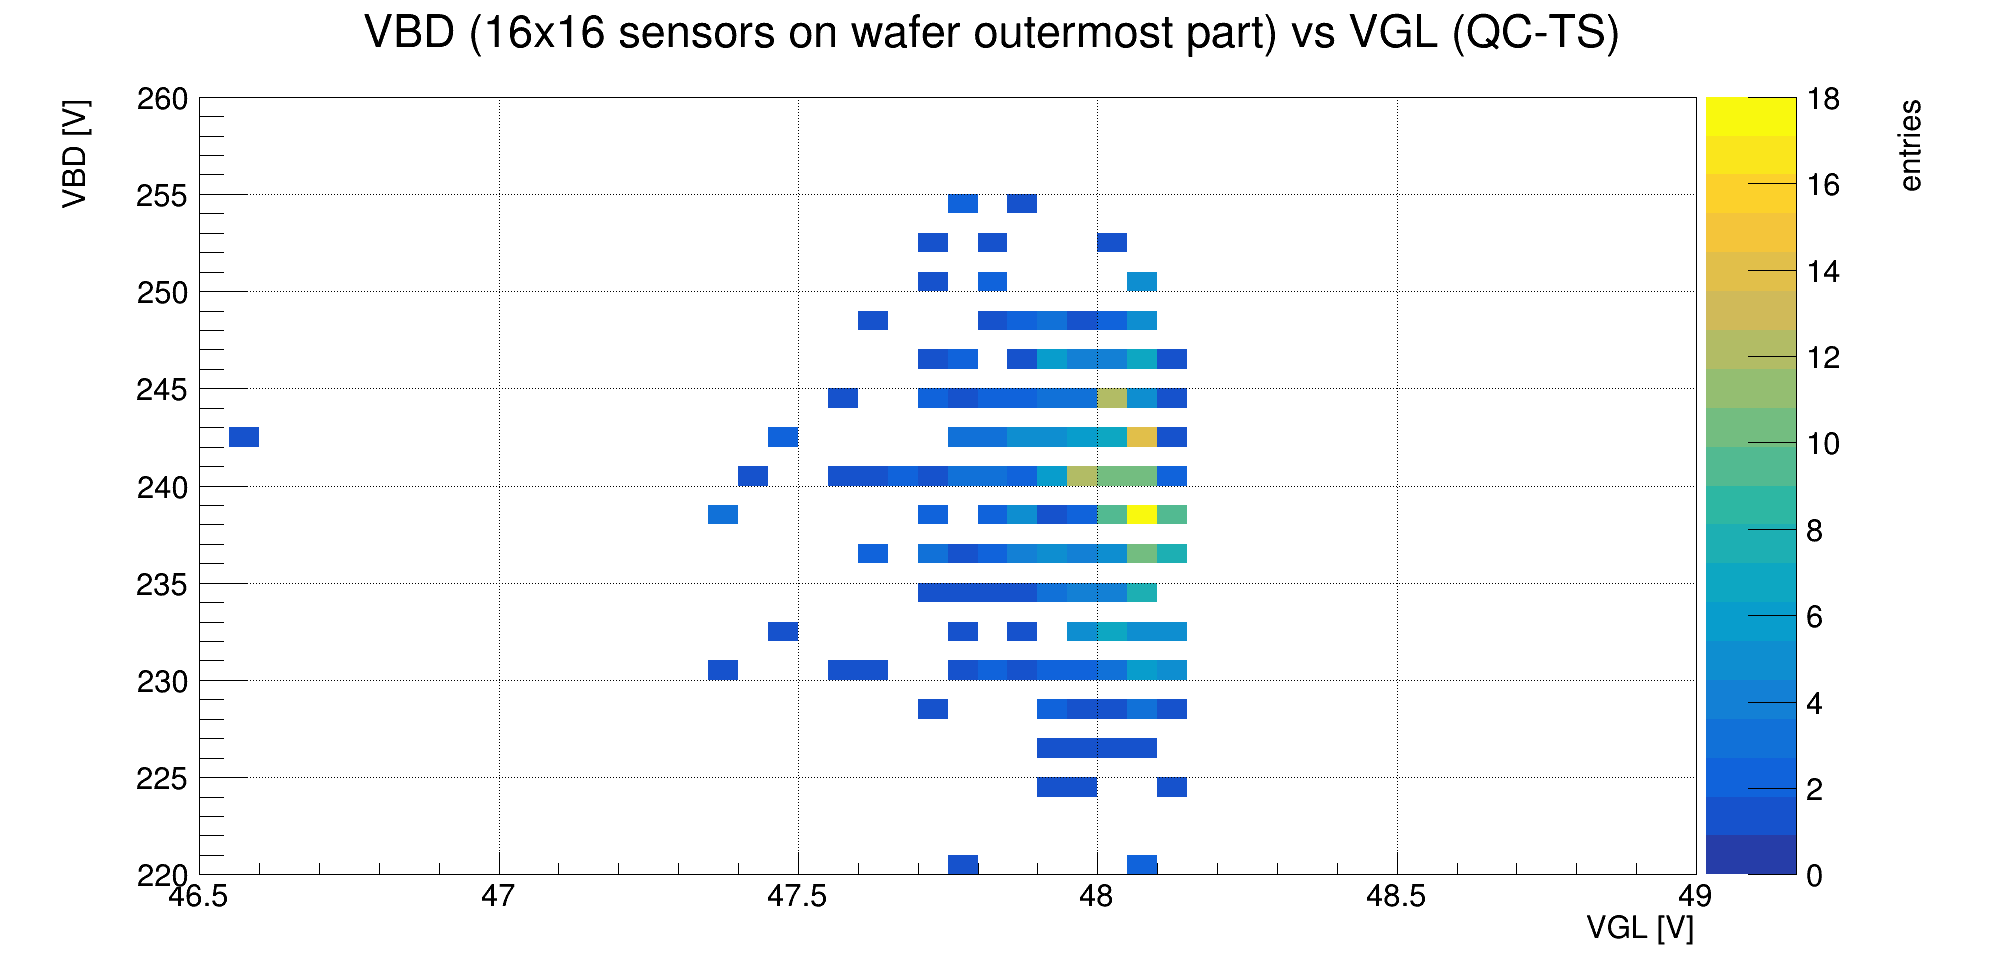

In [3]:
root.gStyle.SetOptStat(0)

start_wafer = 1 #first wafer number in the dataset
start_row = 1 #the first row of the wafer to be measured
start_col = 1 #the first column of the wafer to be measured 

save_path = '/Users/icosivi/Desktop/PRE-SERIE/FBK/'
vbd = []
vgl = []
vbulk = []

with open(save_path+"VBD_list.json", "r", encoding="utf-8") as f:
            vbd =  json.load(f)
            
with open(save_path+"VGL_list.json", "r", encoding="utf-8") as f:
            vgl =  json.load(f)
            
with open(save_path+"Vbulk_list.json", "r", encoding="utf-8") as f:
            vbulk =  json.load(f)
            

vbd_np = np.array(vbd, dtype=float)
vbd_np[vbd_np == 0] = np.nan
vgl_np = np.array(vgl, dtype=float)
vgl_np[vgl_np == 0] = np.nan

vbd_reduced = vbd_np.tolist()
vgl_reduced = vgl_np.tolist()

#vbd_mean = np.nanmean(vbd_np, axis=0)
#vbd_reduced = np.nanconvert = vbd_mean.tolist()

#vgl_mean = np.nanmean(vgl_np, axis=0)
#vgl_reduced = np.nanconvert = vgl_mean.tolist()

#vbd_reduced = np.mean(vbd, axis=0).tolist()
#vgl_reduced = np.mean(vgl, axis=0).tolist()

#print(vbd_reduced)
#print(vgl_reduced)
            
#target_coord = [(1-start_col,6-start_row), (8-start_col,6-start_row), (2-start_col,7-start_row), (7-start_col,7-start_row), (3-start_col,8-start_row), (4-start_col,8-start_row), (5-start_col,8-start_row), (6-start_col,8-start_row)]


#target_set = set(target_coord)
#righe = len(vgl[0])
#colonne = len(vgl[0][0])
'''
vgl_filtered = [
    [layer[j][k] for j in range(8) for k in range(7) if (j, k) not in target_set]
    for layer in vgl
]

vbd_filtered = [
    [layer[j][k] for j in range(7) for k in range(8)]
    for layer in vbd
]
'''

#print(len(vbd_filtered[0]))
#print(len(vgl[0]))

hist = TH2F( "I_qa", "VBD (16x16 sensors on wafer outermost part) vs VGL (QC-TS) ", 50,46.5,49,40,220,260 )

for i in range(13):
    for j in range(8):
        for k in range(7):
         hist.Fill(vgl_reduced[i][j][k],vbd_reduced[i][j][k])

cV_total = root.TCanvas("c_V_all_W", "VBD all W", 2000,1000)

#hist.GetZaxis().SetRangeUser( low_vbd_range, high_vbd_range )
hist.GetZaxis().SetTitle("entries")
hist.GetXaxis().SetTitle("VGL [V]") 
hist.GetYaxis().SetTitle("VBD [V]")
hist.SetMarkerSize(3.)

root.gStyle.SetPaintTextFormat("1.1f")
cV_total.SetRightMargin(0.15)
cV_total.cd()
hist.SetMarkerSize(0.9)
hist.Draw("colz")
root.gPad.SetGrid(1,1)
root.gPad.Update()
cV_total.Update()
#hv_total.GetXaxis().SetNdivisions(n_col)
#hv_total.GetYaxis().SetNdivisions(n_row)
save_path = '/Users/icosivi/Desktop/PRE-SERIE/FBK/'
cV_total.SaveAs(save_path+"VBD_vs_VGL.png")

In [ ]:
#print(len(vbd_filtered[0]))
#print(len(vgl[0]))

hist = TH2F( "I_qaaa", "VBD (16x16 sensors on wafer outermost part) vs VBulk (QC-TS) ", 14,4.,11.,15,230,270 )

for i in range(len(vgl)):
    for j in range(len(vgl[0])):
        hist.Fill(vbulk[i][j],vbd_filtered[i][j])

cV_total = root.TCanvas("c_V_all_Waa", "VBD all W", 2000,1000)

#hist.GetZaxis().SetRangeUser( low_vbd_range, high_vbd_range )
hist.GetZaxis().SetTitle("entries")
hist.GetXaxis().SetTitle("VBulk [V]") 
hist.GetYaxis().SetTitle("VBD [V]")
hist.SetMarkerSize(3.)

root.gStyle.SetPaintTextFormat("1.1f")
cV_total.SetRightMargin(0.15)
cV_total.cd()
hist.SetMarkerSize(0.9)
hist.Draw("colz")
root.gPad.SetGrid(1,1)
root.gPad.Update()
cV_total.Update()
#hv_total.GetXaxis().SetNdivisions(n_col)
#hv_total.GetYaxis().SetNdivisions(n_row)
save_path = '/Users/icosivi/Desktop/PRE-SERIE/HPK/'
cV_total.SaveAs(save_path+"VBD_vs_VBulk.png")